# 超密编码（Superdense Coding）

本文演示了超密编码（Superdense Coding, SDC）协议。

## 1. 超密编码与量子隐形传态的区别

量子隐形传态和超密编码密切相关，为避免混淆，我们需要澄清二者的区别。

量子隐形传态是一种将量子比特（qubit）的状态（ $|\psi\rangle$ ）从一个位置传输到另一个位置的过程，需要使用两个经典比特的通信和一对 Bell 态。换句话说，它是一种在共享纠缠的帮助下，破坏一个位置上量子比特的量子态，并在远处的另一个量子比特上重建该量子态的协议。超密编码是一种允许通信方仅使用一个量子比特传输两个经典比特信息的过程。

| 隐形传态                                           | 超密编码                                               |
|:-------------------------------------------------:|:----------------------------------------------------:|
| 使用两个经典比特传输一个量子比特                    | 使用一个量子比特传输两个经典比特                        |


隐形传态协议可以看作是超密编码协议的翻转版本，即 Alice 和 Bob 只是"交换了设备"。

## 2. 超密编码过程

### 2.1 第一步
该过程由第三方 Charlie 开始。Charlie 准备两个处于纠缠态的量子比特，最初两个量子比特都处于基态 $|0\rangle$。他对第一个量子比特应用 Hadamard 门（$H$）以创建叠加态，然后使用第一个量子比特作为控制，第二个量子比特作为目标应用 CNOT 门（$CX$）。这就是我们之前提到的纠缠态（Bell 对）。

#### 结果状态

我们从以下状态开始：

$$|00\rangle = |0\rangle_A\otimes |0\rangle_B$$

其中将发送给 Alice 的量子比特标记为 $A$，将发送给 Bob 的量子比特标记为 $B$。Charlie 首先对第一个量子比特应用 Hadamard 门，创建叠加态并得到以下状态：

$$|+0\rangle  =  \tfrac{1}{\sqrt{2}}(|00\rangle + |10\rangle)$$

然后 Charlie 应用 CNOT 门。CNOT 门使两个量子比特纠缠在一起，即如果控制量子比特为 $|1\rangle$，则翻转目标量子比特。

$$\text{CNOT} \tfrac{1}{\sqrt{2}}(|00\rangle + |10\rangle) = \tfrac{1}{\sqrt{2}}(|00\rangle + |11\rangle)$$

### 2.2 第二步

Charlie 将第一个量子比特发送给 Alice，将第二个量子比特发送给 Bob。协议的目标是 Alice 使用她的量子比特向 Bob 发送 2 个经典比特的信息。但在此之前，她需要根据想要发送的 2 个比特信息对量子比特应用一组量子门：

#### 超密编码的编码规则（Alice 协议）：

| 预期信息 | 应用的量子门 | 结果状态 ($\cdot\frac{1}{\sqrt{2}}$) |
|:--------:|:------------:|:------------------------------------:|
| 00       | $I$          | $\|00\rangle + \|11\rangle$           |
| 01       | $X$          | $\|10\rangle + \|01\rangle$           |
| 10       | $Z$          | $\|00\rangle - \|11\rangle$           |
| 11       | $ZX$         | $-\|10\rangle + \|01\rangle$          |


因此，如果她想发送 `00`，则不对量子比特做任何操作（应用恒等门 $I$）。如果她想发送 `01`，则应用 $X$ 门。根据她想要发送的信息，Alice 应用适当的量子门，然后将量子比特发送给 Bob 进行最后一步操作。

### 2.3 第三步

Bob 接收 Alice 的量子比特（最左边的量子比特），并使用他的量子比特解码 Alice 的消息。请注意，他不需要知道状态就可以解码它——他只是使用恢复操作。

Bob 使用最左边的量子比特作为控制，最右边的量子比特作为目标应用 CNOT 门。然后他应用 Hadamard 门，最后对两个量子比特进行测量以提取 Alice 的消息。

| Bob 接收到的状态 ($\cdot\tfrac{1}{\sqrt{2}}$) | CNOT 门后的状态 ($\cdot\tfrac{1}{\sqrt{2}}$) | Hadamard 门后的状态 |
|:--------------------------------------------:|:-------------------------------------------:|:------------------:|
|            $\|00\rangle + \|11\rangle$         |            $\|00\rangle + \|10\rangle$         |       $\|00\rangle$ |
|            $\|10\rangle + \|01\rangle$         |            $\|11\rangle + \|01\rangle$         |       $\|01\rangle$ |
|            $\|00\rangle - \|11\rangle$         |            $\|00\rangle - \|10\rangle$         |       $\|10\rangle$ |
|          $-\|10\rangle + \|01\rangle$          |          $-\|11\rangle + \|01\rangle$          |       $\|11\rangle$ |


## 3. 模拟超密编码协议

我们先创建一个纠缠态，需要进行一个 Hadamard 门，然后是一个 CNOT 门。

In [1]:
import deepquantum as dq

def create_bell_pair():
    n_qubits = 2  #定义比特个数
    cir = dq.QubitCircuit(n_qubits)
    cir.h(0)
    cir.cx(0,1)

    return cir

接下来，我们需要编码信息。我们看到可以发送四种可能的信息：`00`、`10`、`01` 或 `11`。让我们创建一个函数，接受这个信息并为我们应用适当的量子门：

In [2]:
def encode_message(cir, qubit, msg):

    if len(msg) != 2 or not set(msg).issubset({"0","1"}):
        raise ValueError(f"message '{msg}' is invalid")
    if msg[1] == "1":
        cir.x(qubit)
    if msg[0] == "1":
        cir.z(qubit)
    return cir

最后，我们需要解码信息，我们看到可以使用一个 CNOT 门和一个 Hadamard 门来完成。让我们也创建一个函数来实现这一点：

In [3]:
def decode_message(cir):
    cir.cx(0,1)
    cir.h(0)
    return cir

最后，我们可以将这些步骤组合起来完成协议。

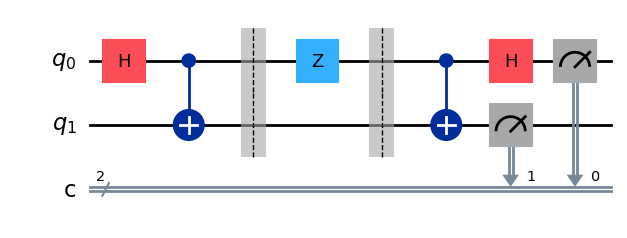

In [4]:
# Charlie 在 Alice 和 Bob 之间创建纠缠对
cir = create_bell_pair()

# 我们添加一个屏障分隔
cir.barrier()

# 此时,量子比特 0 送给 Alice,量子比特 1 送给 Bob
# 接下来,Alice 将她的信息编码到量子比特 1 上。在这个例子中,
# 我们想发送消息 '10'。
message = '10' 
cir = encode_message(cir, 0, message)
cir.barrier()
# 然后 Alice 将她的量子比特发送给 Bob。

# 在接收到量子比特 0 后,Bob 应用恢复协议:
cir = decode_message(cir)

# 最后,Bob 测量他的量子比特来读取 Alice 的消息
cir.measure()

# 绘制输出
cir.draw()

我们可以看到，在没有错误的情况下，我们有 100% 的概率测量到正确的消息。

In [5]:
cir()
cir.measure()

{'10': 1024}